In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.sparse

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import torch.nn.functional as F
from sklearn.metrics import classification_report, f1_score, accuracy_score


df = pd.read_csv("data/nigeria_dataset.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,soil,crop_label
0,40,27,45,21.66,94.79,5.89,112.43,sandy loam,guinea_corn
1,120,7,47,24.25,83.04,6.65,54.77,loamy clay,pepper
2,102,11,47,27.99,92.78,6.50,27.15,sandy loam,tomatoes
3,5,25,6,30.72,94.01,6.01,106.81,loamy,orange
4,36,43,21,28.36,84.86,7.14,52.93,loamy,yam


In [15]:
df['crop_label'].unique()

<StringArray>
['guinea_corn',      'pepper',    'tomatoes',      'orange',         'yam',
       'maize',       'beans',     'soybean',     'cassava',        'rice']
Length: 10, dtype: str

In [16]:
df = df.drop_duplicates()

In [17]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 4335
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1000 non-null   int64  
 1   P            1000 non-null   int64  
 2   K            1000 non-null   int64  
 3   temperature  1000 non-null   float64
 4   humidity     1000 non-null   float64
 5   ph           1000 non-null   float64
 6   rainfall     1000 non-null   float64
 7   soil         1000 non-null   str    
 8   crop_label   1000 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 78.1 KB


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
soil           0
crop_label     0
dtype: int64

In [18]:
target_col = (
    "crop_label" if "crop_label" in df.columns else df.columns[-1]
)

X = df.drop(columns=[target_col])
y = df[target_col]

In [19]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

C:\Users\rmvilla\AppData\Local\Temp\ipykernel_18448\2362020806.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [22]:
X_tr_dense = (
    X_train_processed.toarray()
    if scipy.sparse.issparse(X_train_processed)
    else np.asarray(X_train_processed)
)
X_te_dense = (
    X_test_processed.toarray()
    if scipy.sparse.issparse(X_test_processed)
    else np.asarray(X_test_processed)
)

X_train_tensor = torch.tensor(X_tr_dense, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_te_dense, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [23]:
class LSTMClassifier(nn.Module):

    def __init__(
        self, input_size, hidden_size=128, num_classes=2, dropout_rate=0.3
    ):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size, batch_first=True
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        out = lstm_out[:, -1, :]  # Extract last sequence time-step
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out


num_features = X_tr_dense.shape[1]
num_classes = len(le.classes_)

model = LSTMClassifier(
    input_size=num_features,
    hidden_size=128,
    num_classes=num_classes,
    dropout_rate=0.3,
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model

LSTMClassifier(
  (lstm): LSTM(11, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [24]:
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

epochs = 20

print("Training PyTorch LSTM with Metric Tracking...\n")

for epoch in range(epochs):
    # TRAINING
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()
    
    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # VALIDATION
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            val_running_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
    
    val_loss = val_running_loss / total_val
    val_acc = correct_val / total_val

    # Append to history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch or epoch == 0:
      print(
          f"Epoch {epoch+1:03d}/{epochs} - "
          f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
      )

Training PyTorch LSTM with Metric Tracking...

Epoch 001/20 - loss: 2.2862 - acc: 0.3150 - val_loss: 2.2580 - val_acc: 0.5000
Epoch 002/20 - loss: 2.2099 - acc: 0.4487 - val_loss: 2.1235 - val_acc: 0.5050
Epoch 003/20 - loss: 1.9631 - acc: 0.6375 - val_loss: 1.7161 - val_acc: 0.7000
Epoch 004/20 - loss: 1.4269 - acc: 0.6913 - val_loss: 1.0961 - val_acc: 0.7800
Epoch 005/20 - loss: 0.9082 - acc: 0.7837 - val_loss: 0.7065 - val_acc: 0.8300
Epoch 006/20 - loss: 0.6174 - acc: 0.8125 - val_loss: 0.4938 - val_acc: 0.9250
Epoch 007/20 - loss: 0.4432 - acc: 0.9287 - val_loss: 0.3458 - val_acc: 0.9950
Epoch 008/20 - loss: 0.3111 - acc: 0.9663 - val_loss: 0.2381 - val_acc: 0.9900
Epoch 009/20 - loss: 0.2197 - acc: 0.9812 - val_loss: 0.1628 - val_acc: 0.9950
Epoch 010/20 - loss: 0.1585 - acc: 0.9800 - val_loss: 0.1128 - val_acc: 0.9950
Epoch 011/20 - loss: 0.1119 - acc: 0.9938 - val_loss: 0.0814 - val_acc: 1.0000
Epoch 012/20 - loss: 0.0864 - acc: 0.9912 - val_loss: 0.0647 - val_acc: 1.0000
Epoch

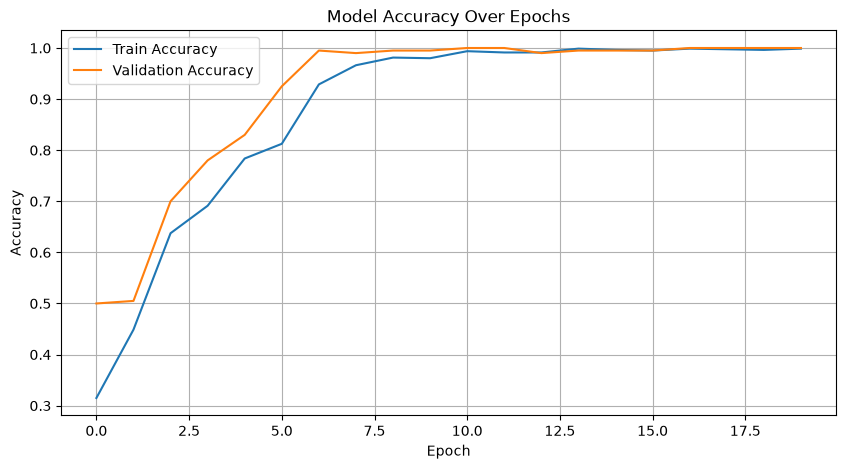

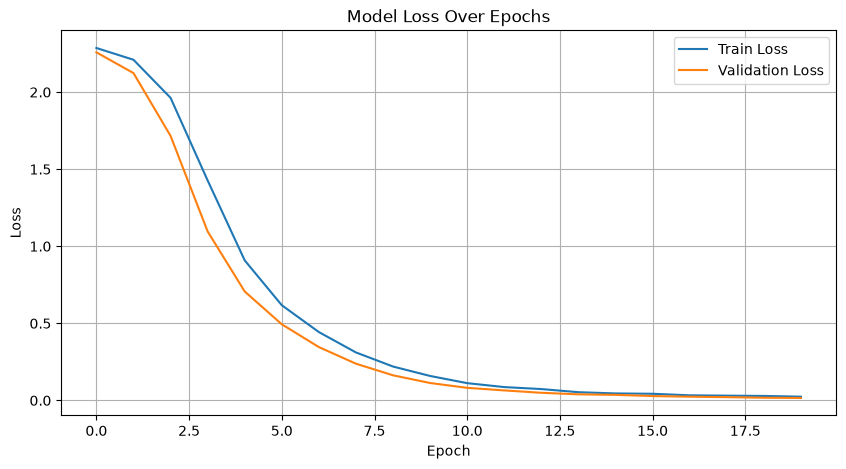

In [25]:
# Accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
if "model_accuracies" not in globals():
  model_accuracies = {}

model.eval()
with torch.no_grad():
  device = next(model.parameters()).device
  test_logits = model(X_test_tensor.to(device))
  _, y_pred_tensor = torch.max(test_logits, dim=1)
  y_pred_lstm = y_pred_tensor.cpu().numpy()

accuracy = accuracy_score(y_test_encoded, y_pred_lstm)
model_accuracies["LSTM"] = accuracy
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(
    classification_report(
        y_test_encoded, y_pred_lstm, target_names=le.classes_
    )
)

Overall Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       beans       1.00      1.00      1.00        20
     cassava       1.00      1.00      1.00        20
 guinea_corn       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      pepper       1.00      1.00      1.00        20
        rice       1.00      1.00      1.00        20
     soybean       1.00      1.00      1.00        20
    tomatoes       1.00      1.00      1.00        20
         yam       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

